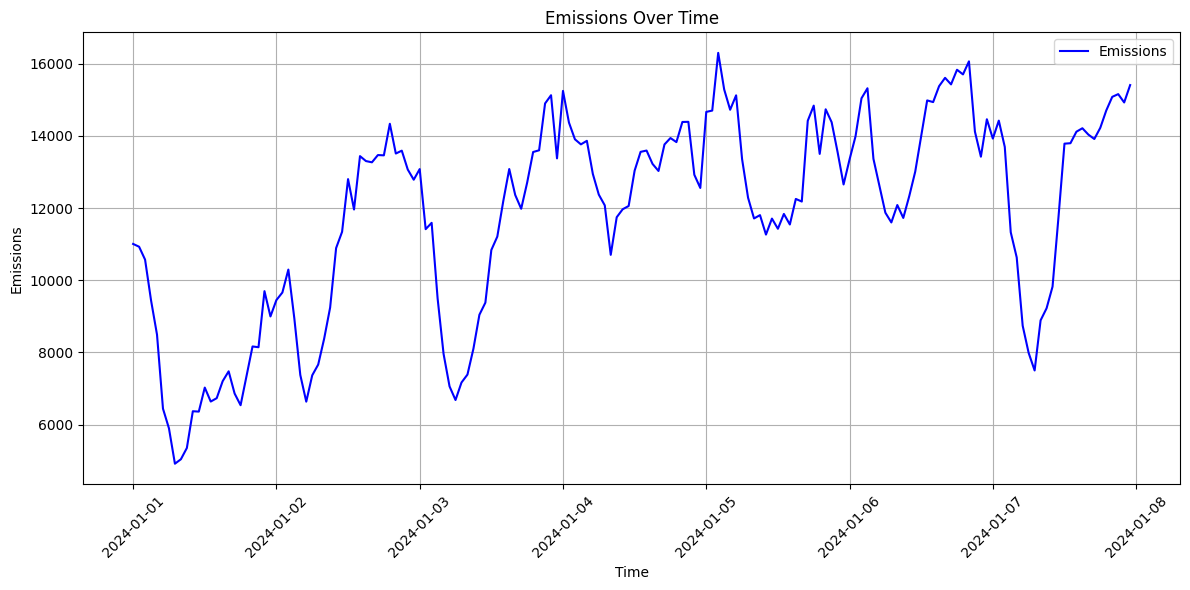

In [3]:
# Cell 1: Import required libraries
import json
import matplotlib.pyplot as plt
from datetime import datetime

# Cell 2: Read the JSON file
# Replace 'checkpoint_hour_168.json' with the path to your JSON file
with open('/home/chad/Desktop/multi-tier-llm-routing-v2/results/2024_hourly_parallel/checkpoint_hour_168.json', 'r') as file:
    data = json.load(file)

# Cell 3: Extract emissions and timestamps
results = data['results']
emissions = [entry['emissions'] for entry in results]
timestamps = [datetime.strptime(entry['timestamp'], '%Y-%m-%dT%H:%M:%S') for entry in results]

# Cell 4: Plot the graph
plt.figure(figsize=(12, 6))
plt.plot(timestamps, emissions, linestyle='-', color='b', label='Emissions')
plt.xlabel('Time')
plt.ylabel('Emissions')
plt.title('Emissions Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

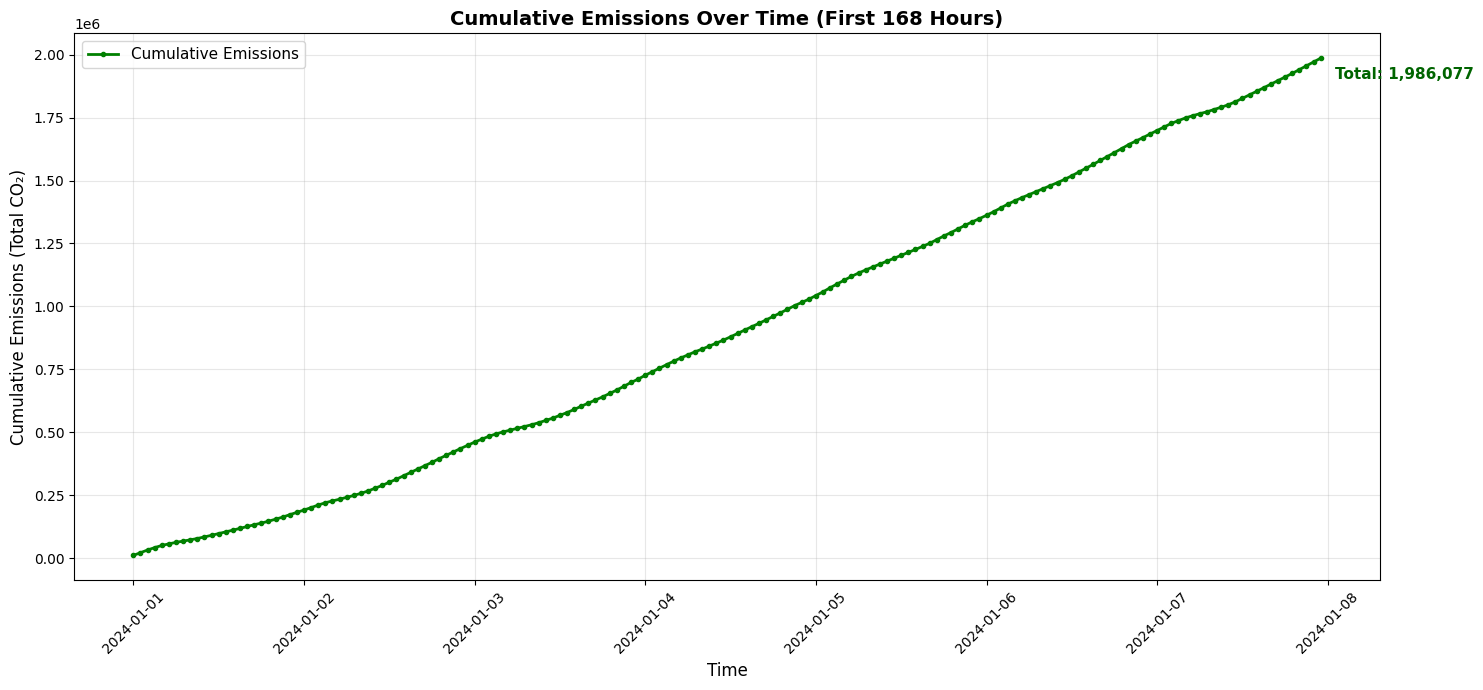

In [2]:
# Cell 1: Import required libraries
import json
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Cell 2: Load the JSON file
# Replace with your actual file path if needed
file_path = '/home/chad/Desktop/multi-tier-llm-routing-v2/results/2024_hourly_parallel/checkpoint_hour_168.json'

with open(file_path, 'r') as f:
    data = json.load(f)

# Cell 3: Extract timestamps and emissions
results = data['results']

# Parse timestamps and get emissions
timestamps = [datetime.strptime(entry['timestamp'], '%Y-%m-%dT%H:%M:%S') for entry in results]
emissions = [entry['emissions'] for entry in results]

# Compute cumulative emissions
cumulative_emissions = np.cumsum(emissions)

# Cell 4: Plot Cumulative Emissions Over Time
plt.figure(figsize=(14, 7))
plt.plot(timestamps, cumulative_emissions, 
         color='green', linewidth=2, marker='o', markersize=3, label='Cumulative Emissions')

# Formatting
plt.xlabel('Time', fontsize=12)
plt.ylabel('Cumulative Emissions (Total CO₂)', fontsize=12)
plt.title('Cumulative Emissions Over Time (First 168 Hours)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.tight_layout()

# Optional: Add total at the end
total_emissions = cumulative_emissions[-1]
plt.annotate(f'Total: {total_emissions:,.0f}', 
             xy=(timestamps[-1], total_emissions),
             xytext=(10, -15), textcoords='offset points',
             fontsize=11, color='darkgreen', fontweight='bold')

plt.show()